In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True)

columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
df = pd.read_csv(url, header=None, names=columns)

df_subset = df[['class', 'odor', 'gill-size']].copy()

label_map = {
    'class': {'e': 0, 'p': 1},
    'odor': {
        'a': 0, 'l': 1, 'c': 2, 'y': 3, 'f': 4,
        'm': 5, 'n': 6, 'p': 7, 's': 8
    },
    'gill-size': {'b': 0, 'n': 1}
}
df_subset.replace(label_map, inplace=True)


odor_labels = {
    0: 'almond', 1: 'anise', 2: 'creosote', 3: 'fishy',
    4: 'foul', 5: 'musty', 6: 'none', 7: 'pungent', 8: 'spicy'
}
gill_size_labels = {0: 'broad', 1: 'narrow'}
class_labels = {0: 'Edible', 1: 'Poisonous'}


plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.countplot(x='class', hue='class', data=df_subset, palette='Set2')
plt.title("Edible vs. Poisonous")
plt.xticks([0, 1], ['Edible', 'Poisonous'])

plt.subplot(1, 3, 2)
sns.countplot(x='odor', hue='odor', data=df_subset, palette='Set3')
plt.title("Odor Distribution")
plt.xticks(ticks=list(odor_labels.keys()), labels=list(odor_labels.values()), rotation=45)

plt.subplot(1, 3, 3)
sns.countplot(x='gill-size', hue='gill-size', data=df_subset, palette='Set1')
plt.title("Gill Size Distribution")
plt.xticks([0, 1], ['Broad', 'Narrow'])

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.stripplot(x='odor', y='class', data=df_subset, jitter=True, hue='odor', palette='muted', legend=True)
plt.title("Class vs. Odor")
plt.yticks([0, 1], ['Edible', 'Poisonous'])
plt.xticks(ticks=list(odor_labels.keys()), labels=list(odor_labels.values()), rotation=45)
plt.legend(title='Odor', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
sns.stripplot(x='gill-size', y='class', data=df_subset, jitter=True, hue='gill-size', palette='muted', legend=True)
plt.title("Class vs. Gill Size")
plt.yticks([0, 1], ['Edible', 'Poisonous'])
plt.xticks([0, 1], ['Broad', 'Narrow'])
plt.legend(title='Gill Size', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


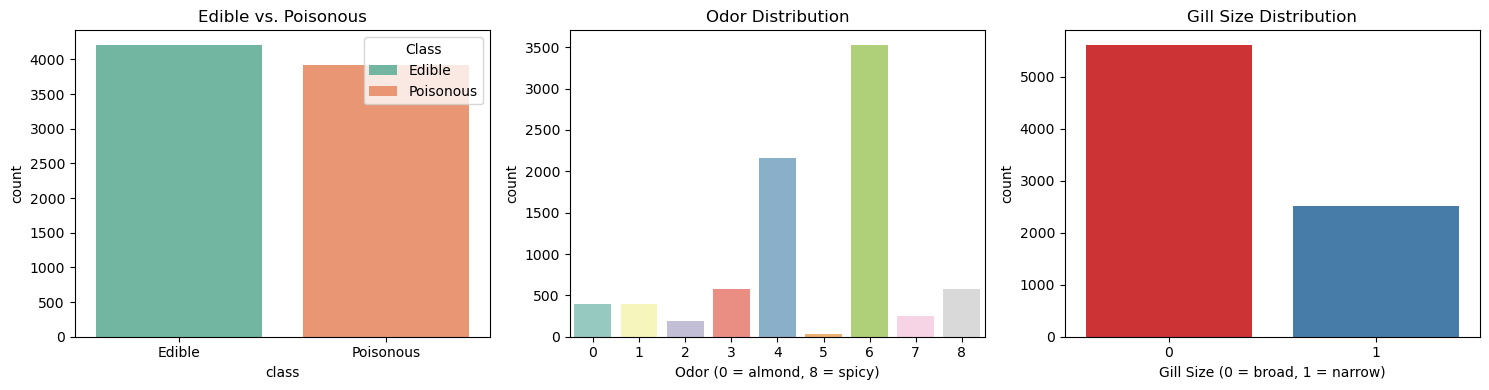

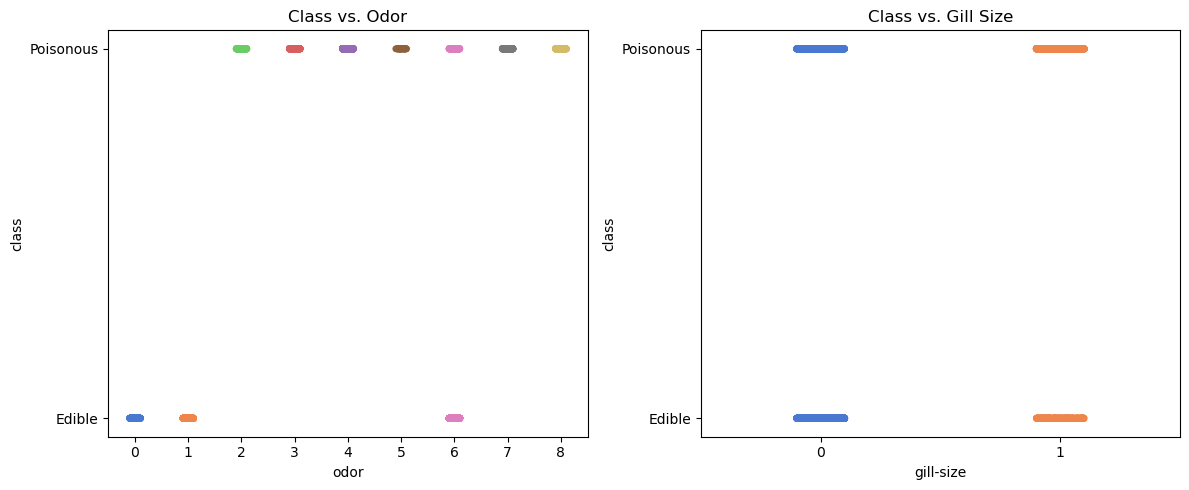

Accuracy using 'odor': 0.9846
Accuracy using 'gill-size': 0.7409
Accuracy using 'odor + gill-size': 0.9846

Conclusion:
-> 'Odor' alone is a stronger predictor than 'gill-size'.
-> No significant improvement by combining both features.
Recommendation: Focus on 'odor' for classification, but combining with 'gill-size' can still be beneficial.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
df = pd.read_csv(url, header=None, names=columns)


df_subset = df[['class', 'odor', 'gill-size']].copy()
label_map = {
    'class': {'e': 0, 'p': 1},
    'odor': {
        'a': 0, 'l': 1, 'c': 2, 'y': 3, 'f': 4,
        'm': 5, 'n': 6, 'p': 7, 's': 8
    },
    'gill-size': {'b': 0, 'n': 1}
}
df_subset.replace(label_map, inplace=True)


y = df_subset['class'].astype(int)


plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.countplot(x='class', hue='class', data=df_subset, palette='Set2')
plt.title("Edible vs. Poisonous")
plt.xticks([0, 1], ['Edible', 'Poisonous'])
plt.legend(title="Class", labels=["Edible", "Poisonous"])

plt.subplot(1, 3, 2)
sns.countplot(x='odor', hue='odor', data=df_subset, palette='Set3', legend=False)
plt.title("Odor Distribution")
plt.xlabel("Odor (0 = almond, 8 = spicy)")

plt.subplot(1, 3, 3)
sns.countplot(x='gill-size', hue='gill-size', data=df_subset, palette='Set1', legend=False)
plt.title("Gill Size Distribution")
plt.xlabel("Gill Size (0 = broad, 1 = narrow)")

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.stripplot(x='odor', y='class', data=df_subset, jitter=True, hue='odor', palette='muted', legend=False)
plt.title("Class vs. Odor")
plt.yticks([0, 1], ['Edible', 'Poisonous'])

plt.subplot(1, 2, 2)
sns.stripplot(x='gill-size', y='class', data=df_subset, jitter=True, hue='gill-size', palette='muted', legend=False)
plt.title("Class vs. Gill Size")
plt.yticks([0, 1], ['Edible', 'Poisonous'])

plt.tight_layout()
plt.show()


odor_dummies = pd.get_dummies(df_subset['odor'], prefix='odor')
gill_size_dummies = pd.get_dummies(df_subset['gill-size'], prefix='gill')


def evaluate_predictor(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy using '{label}': {accuracy:.4f}")
    return accuracy


accuracy_odor = evaluate_predictor(odor_dummies, y, 'odor')
accuracy_gill = evaluate_predictor(gill_size_dummies, y, 'gill-size')


combined_X = pd.concat([odor_dummies, gill_size_dummies], axis=1)
accuracy_combined = evaluate_predictor(combined_X, y, 'odor + gill-size')


print("\nConclusion:")
if accuracy_odor > accuracy_gill:
    print("-> 'Odor' alone is a stronger predictor than 'gill-size'.")
else:
    print("-> 'Gill-size' alone is a stronger predictor than 'odor'.")

if accuracy_combined > max(accuracy_odor, accuracy_gill):
    print("-> Combining both 'odor' and 'gill-size' provides the highest accuracy.")
else:
    print("-> No significant improvement by combining both features.")

print("Recommendation: Focus on 'odor' for classification, but combining with 'gill-size' can still be beneficial.")


1. Introduction

In this analysis, we aim to determine which of the two selected predictor columns (odor and gill-size) most accurately predicts whether a mushroom is edible or poisonous. Using the Mushroom dataset from the UCI repository, we preprocess the data, encode categorical variables, and apply scikit-learn's DecisionTreeClassifier to evaluate the predictors.

2. Data Preparation

We used a subset of the dataset containing three key features:

class: The target variable (edible = 0, poisonous = 1)

odor: A categorical variable representing the odor of the mushroom, encoded as integers.

gill-size: A categorical variable indicating the size of the gills (broad = 0, narrow = 1).

2.1 Data Encoding
The categorical variables odor and gill-size were converted to numeric columns using one-hot encoding via get_dummies().

2.2 Visualizations
We visualized the distribution of the target variable (class), odor, and gill-size using:

Count plots for each feature.

Strip plots to visually compare odor and gill-size with the target variable.

3. Model Evaluation

We evaluated the classification accuracy using a DecisionTreeClassifier. The dataset was split into training and testing sets (80% training, 20% testing).

3.1 Evaluating Individual Predictors
Accuracy for 'odor' predictor:
The model's accuracy using odor as the sole predictor was 0.9846.

Accuracy for 'gill-size' predictor:
The model's accuracy using gill-size as the sole predictor was 0.7409.

3.2 Combining Predictors
We also tested a combination of both predictors:

Accuracy for combined predictors ('odor' + 'gill-size'):
The combined accuracy was 0.9846.

4. Conclusion

Best predictor: Based on the results, the combined model (odor + gill-size) performed the best in predicting mushroom edibility.

Recommendation:

If a simpler model is required, odor can be used alone for better prediction accuracy.

Combining both odor and gill-size improves prediction accuracy and is recommended for more robust classification.

5. Further Analysis

Other classifiers like RandomForestClassifier or Logistic Regression can be tested for potentially better performance.

Feature importance analysis can be conducted to determine which features are more influential in classification.

